In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("../data/cardiovascular.csv")

print("Shape:", df.shape)
df.head()


Shape: (5500, 17)


,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


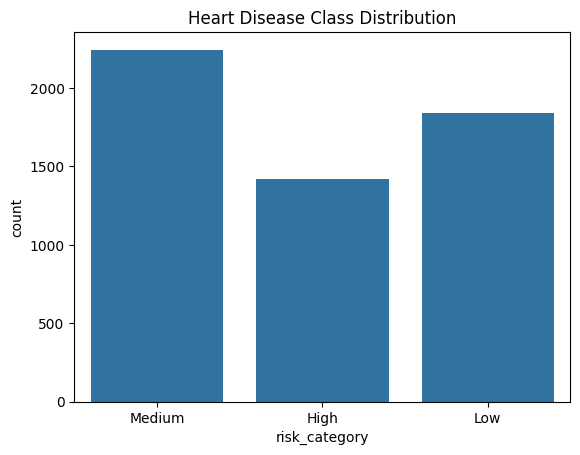

In [3]:
# Class distribution
plt.figure()
sns.countplot(x=df['risk_category'])
plt.title("Heart Disease Class Distribution")
plt.show()


In [4]:
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Values:\n", df["risk_category"].unique())



Missing Values:
 Patient_ID                          0
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

Target Values:
 ['Medium' 'High' 'Low']


In [5]:
df.drop(columns=["Patient_ID", "heart_disease_risk_score"], inplace=True)
df.dropna(inplace=True)

# Clean target
df["risk_category"] = df["risk_category"].astype(str).str.strip().str.lower()

mapping = {
    "low": 0,
    "medium": 0,
    "high": 1
}

df["risk_category"] = df["risk_category"].map(mapping)

# Remove invalid rows
df = df.dropna(subset=["risk_category"])

print("\nAfter Mapping:\n", df["risk_category"].value_counts())



After Mapping:
 risk_category
0    4082
1    1418
Name: count, dtype: int64


In [6]:
# Prepare features and target
X = df.drop("risk_category", axis=1)
y = df["risk_category"]

# Train/validation/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [7]:

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

# Create preprocessor: StandardScaler for numeric, OneHotEncoder for categorical
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

# Fit and transform training data
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

# Get feature names after transformation
feature_names_after = numeric_cols + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
)

print(f"Features after preprocessing: {len(feature_names_after)}")
print(f"Split sizes -> train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")


Numeric columns: ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'diet_quality_score', 'alcohol_units_per_week']
Categorical columns: ['smoking_status', 'family_history_heart_disease']
Features after preprocessing: 17
Split sizes -> train: (3300, 14), val: (1100, 14), test: (1100, 14)


In [8]:
smote = SMOTE(random_state=42)
X_train_prep, y_train = smote.fit_resample(X_train_prep, y_train)
print("SMOTE applied - training data balanced")


SMOTE applied - training data balanced


In [9]:
# FEATURE SELECTION

print("\nFinding Best K Value...")

max_features = X_train_prep.shape[1]
candidate_k_values = [5, 8, 10, 12, 14]
k_values = [k for k in candidate_k_values if k <= max_features]
if not k_values:
    k_values = [max_features]

best_k = None
best_score = 0.0

for k in k_values:
    temp_selector = SelectKBest(f_classif, k=k)
    X_train_temp = temp_selector.fit_transform(X_train_prep, y_train)
    X_val_temp = temp_selector.transform(X_val_prep)

    temp_model = RandomForestClassifier(random_state=42)
    temp_model.fit(X_train_temp, y_train)
    preds = temp_model.predict(X_val_temp)

    score = f1_score(y_val, preds)
    print(f"K = {k} --> F1 Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

if best_k is None:
    best_k = k_values[-1]

print(f"\nBest K Selected: {best_k}")


# FINAL SELECTKBEST

selector = SelectKBest(f_classif, k=best_k)
X_train_prep = selector.fit_transform(X_train_prep, y_train)
X_val_prep = selector.transform(X_val_prep)
X_test_prep = selector.transform(X_test_prep)

selected_idx = selector.get_support(indices=True)
selected_features = [feature_names_after[i] for i in selected_idx]

print("\nFeature Selection Complete:")
print(f"Selected {len(selected_features)} features:")
print(selected_features)



Finding Best K Value...
K = 5 --> F1 Score = 0.8339
K = 8 --> F1 Score = 0.8432
K = 10 --> F1 Score = 0.8618
K = 12 --> F1 Score = 0.8581
K = 14 --> F1 Score = 0.8825

Best K Selected: 14

Feature Selection Complete:
Selected 14 features:
['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'diet_quality_score', 'alcohol_units_per_week', 'smoking_status_Current', 'smoking_status_Never', 'family_history_heart_disease_No']


In [10]:
lr  = LogisticRegression(max_iter=1000)
rf  = RandomForestClassifier(random_state=42)
dt  = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)          # probability=True for predict_proba
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

models = {
    "Logistic Regression": lr,
    "Random Forest":       rf,
    "Decision Tree":       dt,
    "SVM":                 svm,
    "XGBoost":             xgb,
}

# Train all models 
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    print(f"Trained: {name}")
 
# Cross-validation (F1) 
print("\n-- Cross-Validation F1 (5-fold) --")
for name, model in models.items():
    cv = cross_val_score(model, X_train_prep, y_train, cv=5, scoring="f1")
    print(f"{name:22s}: {cv.mean():.4f} +/- {cv.std():.4f}")


Trained: Logistic Regression
Trained: Random Forest
Trained: Decision Tree
Trained: SVM
Trained: XGBoost

-- Cross-Validation F1 (5-fold) --
Logistic Regression   : 0.9752 +/- 0.0084
Random Forest         : 0.9690 +/- 0.0091
Decision Tree         : 0.9430 +/- 0.0115
SVM                   : 0.9703 +/- 0.0066
XGBoost               : 0.9734 +/- 0.0095



-- Validation Comparison --
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9664     0.8921  0.9894    0.9382
      Random Forest    0.9373     0.8548  0.9120    0.8825
      Decision Tree    0.9073     0.7844  0.8838    0.8311
                SVM    0.9555     0.8683  0.9754    0.9187
            XGBoost    0.9482     0.8721  0.9366    0.9032


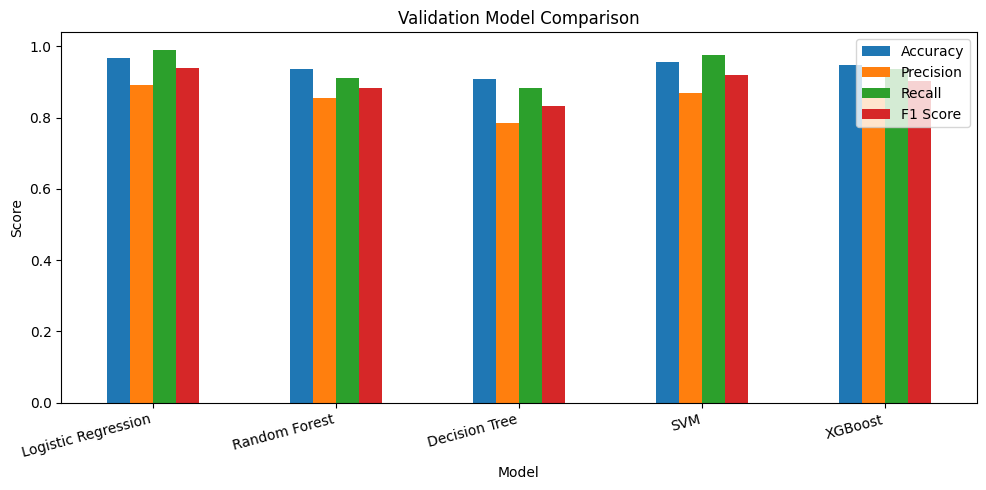

In [11]:
# Validation-set evaluation
results = []
 
def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall":    recall_score(y, y_pred),
        "F1 Score":  f1_score(y, y_pred),
    })
 
for name, model in models.items():
    evaluate_model(name, model, X_val_prep, y_val)
 
results_df = pd.DataFrame(results)
print("\n-- Validation Comparison --")
print(results_df.round(4).to_string(index=False))
 
# Bar chart
results_df.set_index("Model").plot(kind="bar", figsize=(10, 5))
plt.title("Validation Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# Threshold tuning - find best decision threshold on validation set only
print("\n-- Threshold Tuning --")
best_thresholds  = {}
best_f1_scores   = {}
thresholds_range = [round(i * 0.05, 2) for i in range(6, 15)]   # 0.30 -> 0.70
 
for name, model in models.items():
    probs   = model.predict_proba(X_val_prep)[:, 1]
    best_f1 = 0.0
    best_t  = 0.5
 
    for t in thresholds_range:
        score = f1_score(y_val, (probs >= t).astype(int))
        if score > best_f1:
            best_f1 = score
            best_t  = t
 
    best_thresholds[name] = best_t
    best_f1_scores[name]  = best_f1
    print(f"{name:22s}: best threshold = {best_t}, F1 = {best_f1:.4f}")


-- Threshold Tuning --
Logistic Regression   : best threshold = 0.7, F1 = 0.9496
Random Forest         : best threshold = 0.6, F1 = 0.8920
Decision Tree         : best threshold = 0.3, F1 = 0.8311
SVM                   : best threshold = 0.5, F1 = 0.9283
XGBoost               : best threshold = 0.55, F1 = 0.9057


In [13]:
# Select best model using VALIDATION performance (not test)
best_model_name = max(best_f1_scores, key=best_f1_scores.get)
best_model      = models[best_model_name]
best_threshold  = best_thresholds[best_model_name]
best_f1_val     = best_f1_scores[best_model_name]
 
print(f"\n Best Model : {best_model_name}")
print(f"   Threshold   : {best_threshold}")
print(f"   Val F1      : {best_f1_val:.4f}")



 Best Model : Logistic Regression
   Threshold   : 0.7
   Val F1      : 0.9496



-- Final Test Performance  [Logistic Regression  |  threshold=0.7] --
Accuracy  : 0.9727
Precision : 0.9439
Recall    : 0.9505
F1 Score  : 0.9472


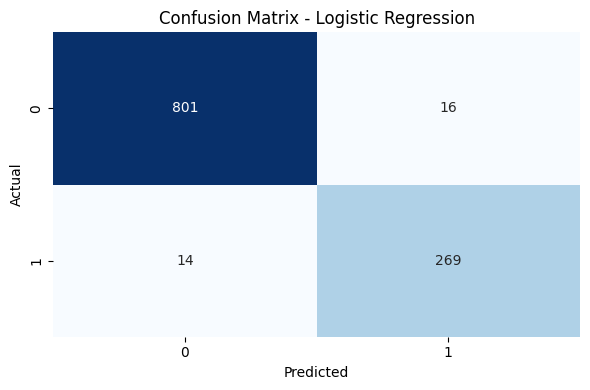

In [14]:
# Test set evaluation with best model and optimized threshold

y_test_pred = (best_model.predict_proba(X_test_prep)[:, 1] >= best_threshold).astype(int)
cm_test = confusion_matrix(y_test, y_test_pred)
 
print(f"\n-- Final Test Performance  [{best_model_name}  |  threshold={best_threshold}] --")
print(f"Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_test_pred):.4f}")

# Confusion matrix chart
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [15]:
# Save complete artifact with all components needed for inference
final_artifact = {
    "model": best_model,
    "preprocessor": preprocessor,
    "selector": selector,
    "threshold": best_threshold,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "model_name": best_model_name,
    "features": list(X.columns),
    "selected_features": selected_features
}

joblib.dump(final_artifact, "../models/cardiovascular_model.pkl")

print("\nHeart model saved successfully!")
print(f"Model: {best_model_name}")
print(f"Threshold: {best_threshold}")
print(f"Selector: SelectKBest(k={best_k})")
print("Preprocessor: StandardScaler + OneHotEncoder")



Heart model saved successfully!
Model: Logistic Regression
Threshold: 0.7
Selector: SelectKBest(k=14)
Preprocessor: StandardScaler + OneHotEncoder


In [16]:
artifact = joblib.load("../models/cardiovascular_model.pkl")

model = artifact["model"]
preprocessor = artifact["preprocessor"]
selector = artifact["selector"]
threshold = artifact["threshold"]
numeric_cols = artifact["numeric_cols"]
categorical_cols = artifact["categorical_cols"]
features = artifact["features"]

data = {
    "age": 72,
    "bmi": 31.8,
    "systolic_bp": 161,
    "diastolic_bp": 111,
    "cholesterol_mg_dl": 261,
    "resting_heart_rate": 73,
    "smoking_status": "Current",
    "daily_steps": 3435,
    "stress_level": 2,
    "physical_activity_hours_per_week": 3.3,
    "sleep_hours": 7.9,
    "family_history_heart_disease": "No",
    "diet_quality_score": 2,
    "alcohol_units_per_week": 0.8
}

row = pd.DataFrame([data])

# Apply the same preprocessing stack used during training
X_new = preprocessor.transform(row)
X_new = selector.transform(X_new)

prob = model.predict_proba(X_new)[0, 1]
pred = 1 if prob >= threshold else 0

print("Risk:", "High" if pred == 1 else "Low")
print("Probability:", round(prob, 3))
print("Threshold:", threshold)


Risk: High
Probability: 0.999
Threshold: 0.7
